# Replication: Blanchard & Perotti (2002)
### By Constantino Hevia with the help of Claude

**Reference.** Blanchard, O. and Perotti, R. (2002). "An Empirical Characterization of the Dynamic Effects of Changes in Government Spending and Taxes on Output." *Quarterly Journal of Economics*, 117(4), 1329–1368.

This notebook replicates the three-variable structural VAR (SVAR) of Blanchard–Perotti (BP) using **current FRED data**, and documents carefully where the replication succeeds and where it does not.

## Headline finding

- The **government-spending multiplier** reproduces almost exactly (contemporaneous $c_2 \approx 0.95$ vs BP's $0.956$), with no special data treatment.
- The **tax multiplier** does **not** reproduce out of the box. With current NIPA data, net taxes are slightly *too procyclical* and the tax channel collapses to ≈ 0. The cause is the **accrual-basis corporate income tax**, which BP replace with **cash-basis** Treasury data. We cannot replicate that data swap with FRED, so we approximate its effect with a short moving average (a proxy for collection lags). Under that proxy the tax channel reappears with the correct sign and a magnitude in BP's lower range.

The point of the exercise is therefore not to force BP's decimals, but to **locate precisely where the paper's results are fragile**: the spending channel is robust to data vintage; the tax channel hinges on a data-construction detail buried in the paper's appendix.


## Methodology

### The VAR

BP estimate a quarterly VAR in $Y_t=[T_t, G_t, X_t]'$ — net taxes, government spending, and GDP — all in **logs of real, per-capita** terms:

$$Y_t = A(L)\,Y_{t-1} + U_t,\qquad U_t=[v^T_t, v^G_t, v^X_t]'$$

with 4 lags, deterministic trends, and a dummy for the 1975:2 tax rebate (details below). $U_t$ are the reduced-form residuals.

### Identification

The reduced-form residuals are linked to the mutually orthogonal structural shocks $\varepsilon=[\varepsilon^T,\varepsilon^G,\varepsilon^X]$ by:

$$v^T_t = a_1 v^X_t + a_2\varepsilon^G_t + \varepsilon^T_t$$
$$v^G_t = b_1 v^X_t + b_2\varepsilon^T_t + \varepsilon^G_t$$
$$v^X_t = c_1 v^T_t + c_2 v^G_t + \varepsilon^X_t$$

The identification has three steps:

1. **Impose external elasticities** $a_1, b_1$ from institutional information. $a_1 = 2.08$ is BP's output elasticity of net taxes (computed in their appendix from disaggregated tax-base elasticities); $b_1 = 0$ because government purchases have no automatic within-quarter response to output. With quarterly data, decision/implementation lags rule out any *discretionary* within-quarter response, so $a_1,b_1$ capture only automatic stabilizers.

2. **Construct cyclically-adjusted residuals** $\eta^T_t = v^T_t - a_1 v^X_t$ and $\eta^G_t = v^G_t$ (since $b_1=0$). These are purged of the automatic response to output, so they are uncorrelated with $\varepsilon^X$ and can serve as **instruments** to estimate $c_1, c_2$ in a regression of $v^X_t$ on $v^T_t, v^G_t$.

3. **Order the fiscal shocks.** We use "spending first" ($b_2=0$) and estimate $a_2$. BP show the ordering barely matters because $\mathrm{corr}(\eta^T_t,\eta^G_t)$ is small.


### A note on the data vintage

BP use the original Citibase/NIPA vintage. We use current (revised) FRED data. The goal is to reproduce **signs, shapes, and approximate magnitudes**, not exact decimals.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, solve
from fredapi import Fred
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 120,
})
rng = np.random.default_rng(42)

## 1. Data

All variables are **general government** (federal + state + local, consolidated), **real** (deflated by the GDP deflator), **per capita**, and in **logs**. Following BP we deflate everything by the *same* GDP deflator, which lets impulse responses be read as shares of GDP (BP footnote 2).

| Concept | Definition (BP) | FRED series |
|---|---|---|
| GDP $X$ | nominal GDP, deflated, per capita | `GDP` |
| Spending $G$ | purchases of goods & services = consumption + gross investment | `GCE` |
| Net taxes $T$ | total receipts − transfers − net interest | `W066RC1Q027SBEA` − `A084RC1Q027SBEA` − `A180RC1Q027SBEA` |
| Corporate tax | taxes on corporate income (for the proxy in §2) | `W025RC1Q027SBEA` |
| Deflator | GDP implicit price deflator | `GDPDEF` |
| Population | civilian noninstitutional population | `CNP16OV` |

**Construction notes.**
- $G$ is *purchases of goods and services only*. It is **not** total expenditures (which would include transfers and interest). BP put transfers and interest *inside* net taxes, with a negative sign — that is why they belong in $T$, not $G$.
- $T$ is *net* taxes: receipts net of transfers and interest. Using the consolidated general-government totals is cleaner than summing federal + state/local separately, because intergovernmental grants-in-aid (which BP subtract by hand) cancel automatically on consolidation.
- Units: via `fredapi` these NIPA series arrive already in **billions of dollars**, the same units as `GDP` and `GCE`, so no rescaling is applied. (If your `fredapi`/FRED build returns them in **millions**, divide `tax_nom` and `corp` by 1000 — the scale-check cell below will flag it either way. Consistent units matter for the dollar-for-dollar IRF normalization in §6.)
- We download from 1958 so the four VAR lags come from real observations; estimation effectively starts in 1960Q1, BP's benchmark sample start.


In [5]:
API_KEY = os.environ.get('FRED_API_KEY', 'PONER ACÁ TU FRED API KEY')
fred = Fred(api_key=API_KEY)

START, END = '1958-01-01', '1997-12-31'

gdp_nom   = fred.get_series('GDP',            observation_start=START, observation_end=END)  # $bn SAAR
deflator  = fred.get_series('GDPDEF',         observation_start=START, observation_end=END)  # 2017=100
gce       = fred.get_series('GCE',            observation_start=START, observation_end=END)  # $bn SAAR
receipts  = fred.get_series('W066RC1Q027SBEA',observation_start=START, observation_end=END)  # $M, total receipts
transfers = fred.get_series('A084RC1Q027SBEA',observation_start=START, observation_end=END)  # $M
interest  = fred.get_series('A180RC1Q027SBEA',observation_start=START, observation_end=END)  # $M
corp      = fred.get_series('W025RC1Q027SBEA',observation_start=START, observation_end=END)  # $M, corporate tax
pop       = fred.get_series('CNP16OV',        observation_start=START, observation_end=END).resample('QS').mean()

df_raw = pd.DataFrame({'gdp_nom':gdp_nom,'deflator':deflator,'gce':gce,
                       'receipts':receipts,'transfers':transfers,'interest':interest,
                       'corp':corp,'pop':pop}).dropna()

# Net taxes (full): W/A series already arrive in $bn via fredapi (same as GDP/GCE), so NO /1000
df_raw['tax_nom'] = df_raw['receipts'] - df_raw['transfers'] - df_raw['interest']
df_raw['corp_bn'] = df_raw['corp']

# real per-capita helper (deflator in proportion, pop in millions)
defl = df_raw['deflator']/100
popm = df_raw['pop']/1000
real_pc = lambda s: s / defl / popm

# Levels (needed later for the dollar-for-dollar IRF normalization)
X_lvl = real_pc(df_raw['gdp_nom'])
G_lvl = real_pc(df_raw['gce'])
T_lvl = real_pc(df_raw['tax_nom'])

df = pd.DataFrame(index=df_raw.index)
df['X'] = np.log(X_lvl)
df['G'] = np.log(G_lvl)
df['T'] = np.log(T_lvl)

# trim: keep 1958-59 only as lag feed; estimation sample starts 1960Q1
df  = df.loc['1959-01-01':'1997-10-01']

print(f"Estimation feed: {df.index[0].date()} .. {df.index[-1].date()}  ({len(df)} obs)")
print(f"Net taxes / GDP (mean): {(T_lvl/X_lvl).loc[df.index].mean():.3f}  (expect ~0.13-0.16)")
print(f"Spending  / GDP (mean): {(G_lvl/X_lvl).loc[df.index].mean():.3f}  (expect ~0.18-0.22)")
print(f"T positive throughout : {(T_lvl.loc[df.index]>0).all()}")
df.tail()

# --- scale sanity check (catches any unit/factor slip immediately) ---
_ty = (T_lvl/X_lvl).loc[df.index].mean()
_gy = (G_lvl/X_lvl).loc[df.index].mean()
assert 0.10 < _ty < 0.20, f"Net taxes/GDP = {_ty:.5f} out of range -- check units (factor of 1000?)"
assert 0.15 < _gy < 0.25, f"Spending/GDP = {_gy:.5f} out of range -- check units"
print("scale check OK")

Estimation feed: 1959-01-01 .. 1997-10-01  (156 obs)
Net taxes / GDP (mean): 0.140  (expect ~0.13-0.16)
Spending  / GDP (mean): 0.215  (expect ~0.18-0.22)
T positive throughout : True
scale check OK


## 2. The corporate-tax proxy (cash-basis approximation)

This is the crux of why the tax channel is hard to replicate, so we are explicit about it.

**What BP do.** For *federal corporate income taxes*, BP do **not** use the NIPA series (which is on an **accrual** basis). They substitute **cash-basis** data from the *Quarterly Treasury Bulletin* (appendix, footnote 22), and they model collection lags explicitly when constructing the tax elasticity $a_1$. Accrual-basis corporate taxes are recorded when profits are *earned*, so they move in lockstep with profits — which are hypersensitive to the cycle (BP estimate an elasticity of profits to GDP of 4.50 at quarterly frequency). Cash receipts, by contrast, arrive in estimated installments and are reconciled with a lag, so they are mechanically **decoupled** from contemporaneous profits and far less procyclical.

**Why this breaks the FRED replication.** The sign of $c_1$ is governed, to first order, by
$$\operatorname{sign}(c_1)\;\approx\;\operatorname{sign}(a_1 - b_{\text{ols}}),$$
where $b_{\text{ols}}$ is the OLS slope of $v^T$ on $v^X$. BP get $c_1<0$ because in their (cash-corrected) data $a_1=2.08$ **exceeds** $b_{\text{ols}}$. In current NIPA data the *accrual* corporate tax pushes $b_{\text{ols}}$ up to $\approx 2.11 > 2.08$, so $c_1$ collapses to ≈ 0. A 10%-of-receipts component flips the entire tax channel — purely through its **comovement** with output, not its volatility.

**Our proxy.** The Treasury cash-basis series is not on FRED. As an approximation we replace the accrual corporate tax inside net taxes by a short **moving average** of itself. This reproduces the *first-order effect of collection lags* (decoupling corporate receipts from contemporaneous profits)  without claiming to replicate BP's data swap.

> **This is a proxy, not BP's method.** BP use a different *data source* (cash-basis Treasury data); we apply a smoothing *transformation* to the accrual data as a stand-in for collection lags. The finding (the tax channel hinges on corporate-tax procyclicality) is robust to the smoothing window; only the exact decimal of $c_1$ depends on it. A fully faithful replication would require the cash-basis Treasury/MTS series or Perotti's original dataset.

We use a window of **2 quarters** (the mildest smoothing that flips the sign — the most conservative choice) and keep $a_1=2.08$ and the net-tax definition unchanged.


In [7]:
W_SMOOTH = 2   # moving-average window: proxy for corporate-tax collection lags

# Smoothed corporate tax -> rebuild net taxes keeping everything else fixed
corp_sm = df_raw['corp_bn'].rolling(W_SMOOTH, min_periods=1).mean()
tax_sm  = df_raw['tax_nom'] - df_raw['corp_bn'] + corp_sm  # Resto el corporativo raw y sumo el ajustado
T_sm_lvl = real_pc(tax_sm)

df['T_sm'] = np.log(T_sm_lvl).loc[df.index]

# Mean GDP-share ratios (used for the dollar-for-dollar IRF conversion)
T_Y    = (T_lvl   / X_lvl).loc[df.index].mean()
T_Y_sm = (T_sm_lvl/ X_lvl).loc[df.index].mean()
G_Y    = (G_lvl   / X_lvl).loc[df.index].mean()
print(f"corporate tax share of receipts: {(df_raw['corp_bn']/(df_raw['tax_nom']+df_raw['transfers']/1000+df_raw['interest']/1000)).mean():.3f}")
print(f"T/Y full = {T_Y:.3f}   T/Y smoothed = {T_Y_sm:.3f}   G/Y = {G_Y:.3f}")

corporate tax share of receipts: 0.202
T/Y full = 0.140   T/Y smoothed = 0.140   G/Y = 0.215


## 3. Data, BP Figures I–II

BP's Figure I plots net taxes and spending as **shares of GDP**; Figure II plots $\log(T)-\log(G)$. These are the economically meaningful views: the 1975:2 rebate, the low-frequency swings that motivate the deterministic-vs-stochastic-trend discussion, etc. (The Korean-War spending step that opens BP's Figure I is outside our 1959+ window, which is exactly why the estimation sample is post-1960.)


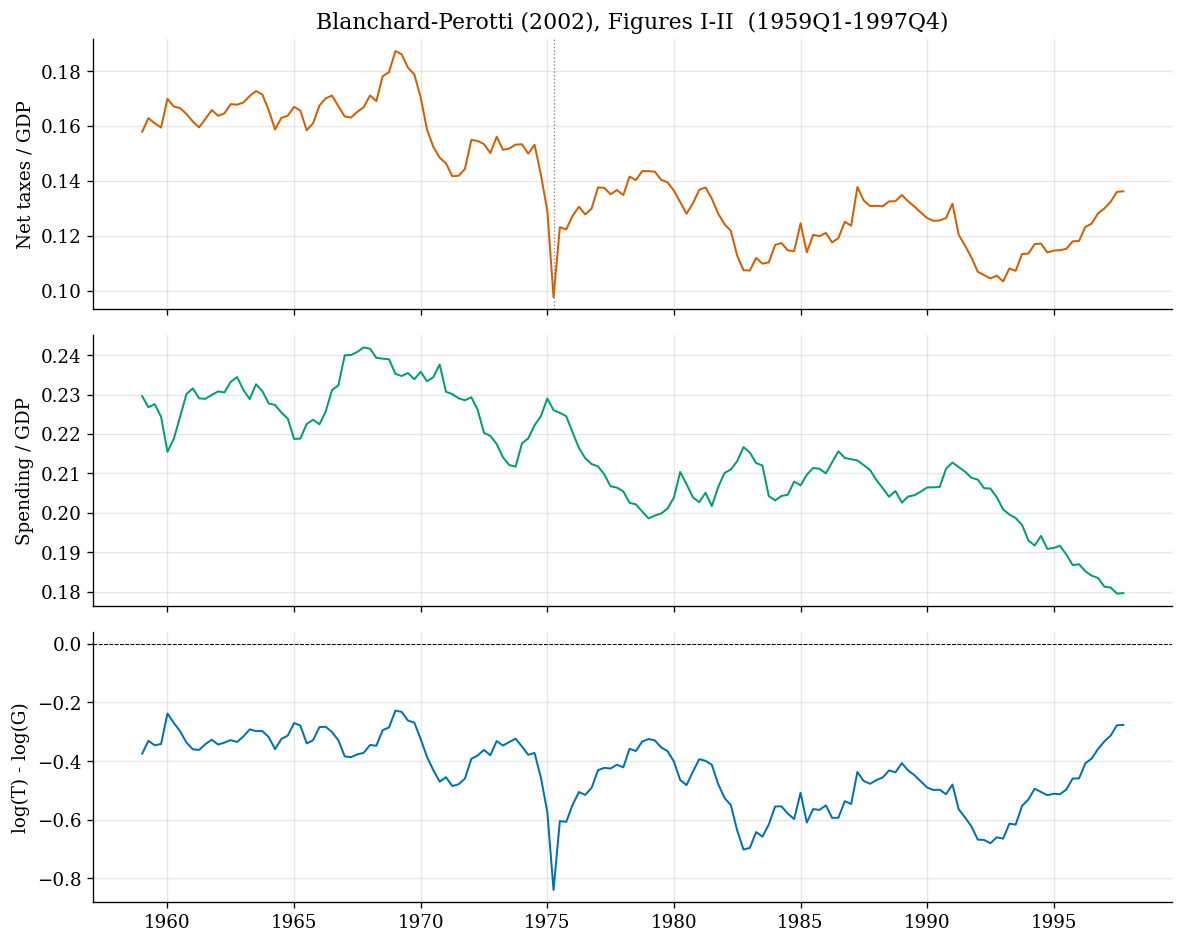

In [9]:
fig, ax = plt.subplots(3,1, figsize=(10,8), sharex=True)

ax[0].plot(df.index, (T_lvl/X_lvl).loc[df.index], color='#D55E00', lw=1.2)
ax[0].set_ylabel('Net taxes / GDP'); ax[0].axvline(pd.Timestamp('1975-04-01'), color='gray', ls=':', lw=.8)
ax[1].plot(df.index, (G_lvl/X_lvl).loc[df.index], color='#009E73', lw=1.2)
ax[1].set_ylabel('Spending / GDP')
ax[2].plot(df.index, (df['T']-df['G']), color='#0072B2', lw=1.2)
ax[2].set_ylabel('log(T) - log(G)'); ax[2].axhline(0, color='k', ls='--', lw=.6)
ax[0].set_title('Blanchard-Perotti (2002), Figures I-II  (1959Q1-1997Q4)')

for a in ax:
    a.grid(True, alpha=0.3)
    
fig.tight_layout(); 
fig.savefig('bp_fig1_data.pdf', bbox_inches='tight'); 
plt.show()

## 4. VAR specification and core estimation functions

Following BP's deterministic-trend (DT) benchmark: 4 lags, constant + **linear and quadratic** time trends, and a **1975:2 dummy with its current value and 4 lags** (= 5 one-hot columns at 1975Q2, Q3, Q4, 1976Q1, 1976Q2). Sample 1960Q1–1997Q4.

We estimate the VAR by OLS on an explicit design matrix (rather than a library wrapper). This keeps the exogenous dummies and the structural identification fully transparent and lets us reuse the exact same code in the bootstrap.


In [11]:
NLAGS = 4

def build_design(Ymat, idx, nlags, Dexog):
    '''Design matrix for VAR(nlags) with const + linear + quad trend + exog dummies.
    Returns Z (T_eff x kreg), Ydep (T_eff x k), and offset where AR lag blocks start.'''
    n, k = Ymat.shape
    Teff = n - nlags
    t = np.arange(nlags, n)
    tt = (t - t.mean())/t.std()                 # scaled trend (well-conditioned)
    det = np.column_stack([np.ones(Teff), tt, tt**2])    # const, trend, trend^2
    Dx  = Dexog[nlags:]                                   # dummy block, aligned
    lags = np.column_stack([Ymat[nlags-l-1 : n-l-1] for l in range(nlags)])  # Y_{t-1..t-nlags}
    Z = np.column_stack([det, Dx, lags])
    Ydep = Ymat[nlags:]
    offset = det.shape[1] + Dx.shape[1]         # where AR blocks begin
    return Z, Ydep, offset

def ols_var(Z, Ydep, offset, nlags, k):
    '''OLS VAR. Returns AR coefs (nlags,k,k), residuals, and fitted values.'''
    B = solve(Z.T@Z, Z.T@Ydep)                  # (kreg, k)
    resid  = Ydep - Z@B
    fitted = Z@B
    coefs = np.array([B[offset+l*k : offset+(l+1)*k, :].T for l in range(nlags)])  # [lag][eq,var]
    return coefs, resid, fitted, B

def ma_rep(coefs, horizon):
    '''MA matrices Phi_0..Phi_h (Phi_0=I) from AR coefs.'''
    nlags, k, _ = coefs.shape
    phis = [np.eye(k)]
    for h in range(1, horizon+1):
        phi = np.zeros((k,k))
        for i in range(1, min(h, nlags)+1):
            phi += phis[h-i] @ coefs[i-1]
        phis.append(phi)
    return np.array(phis)

# 1975:2 dummy + 4 lags = 5 one-hot columns
DUMMY_Q = ['1975-04-01','1975-07-01','1975-10-01','1976-01-01','1976-04-01']
def make_dummies(idx):
    D = np.zeros((len(idx), len(DUMMY_Q)))
    for j,d in enumerate(DUMMY_Q):
        pos = idx.get_indexer([pd.Timestamp(d)])
        if pos[0] >= 0: D[pos[0], j] = 1.0
    return D

## 5. Identification and impulse-response functions

`identify_bp` implements the three-step BP identification (impose $a_1,b_1$; estimate $a_2$ under spending-first; IV for $c_1,c_2$) and returns the structural impact matrix $S$ such that $U = S\varepsilon$.

`structural_irf` propagates a unit structural shock through the VAR's MA representation.

**Dollar-for-dollar normalization.** BP report responses as the dollar change in each variable per \$1 of the fiscal shock. Because every variable is in logs of real per-capita terms deflated by the *same* GDP deflator, a log response converts to a share-of-GDP response by multiplying by the variable's mean ratio to GDP.

Define the mean GDP shares $V_Y \equiv \bar v / \bar X$ (so $T_Y = \bar T/\bar X$, $G_Y = \bar G/\bar X$, and $X_Y = 1$). The dollar response of variable $v$ at horizon $h$ to a shock in fiscal variable $f$ is

$$\text{dollar IRF}_{v}(h) \;=\; \text{irf}^{\log}_{v}(h)\;\times\;\frac{V_Y}{F_Y},$$

i.e. scale the raw log-IRF of $v$ by its own GDP share and divide by the shock variable's GDP share. For a spending shock ($f=G$), the GDP response is $\text{irf}^{\log}_X(h)/G_Y$; for a tax shock, $\text{irf}^{\log}_X(h)/T_Y$.

**Why the impact differs from $c_2$.** The contemporaneous coefficient $c_2$ (BP Table II) is a *structural* parameter — the direct effect of $g$ on $x$. The IRF impact $S_{X,G}$ (BP Table IV) is the *reduced-form* response, which also embeds the full simultaneous feedback running through the system. The two coincide only when $c_1 = 0$; once $c_1 \neq 0$, a spending shock moves output, which moves taxes, which feeds back into output, so $S_{X,G} \neq c_2$. Both numbers are correct and BP report both.

In [13]:
def identify_bp(resid, a1, b1=0.0):
    '''BP identification. resid cols = [T,G,X]. Spending-first ordering (b2=0).'''
    vT, vG, vX = resid[:,0], resid[:,1], resid[:,2]
    tprime = vT - a1*vX
    gprime = vG - b1*vX
    eps_G  = gprime.copy()
    a2 = (eps_G @ tprime)/(eps_G @ eps_G)
    eps_T = tprime - a2*eps_G
    # IV: instruments [eps_T, eps_G] for endogenous [vT, vG] in vX = c1 vT + c2 vG + eps_X
    Z  = np.column_stack([eps_T, eps_G]); Xe = np.column_stack([vT, vG])
    c1, c2 = solve(Z.T@Xe, Z.T@vX)
    A = np.array([[1,0,-a1],[0,1,-b1],[-c1,-c2,1.0]])
    B = np.array([[1,a2,0],[0,1,0],[0,0,1.0]])
    S = inv(A)@B
    return dict(a1=a1,b1=b1,a2=a2,c1=c1,c2=c2,S=S)

def structural_irf(coefs, S, shock_col, horizon):
    phis = ma_rep(coefs, horizon)
    s = S[:, shock_col]
    return np.array([phis[h] @ s for h in range(horizon+1)])

def to_dollar(irf_log, shock_col, V_Y):
    '''Dollar-for-dollar conversion. V_Y = [T_Y, G_Y, 1.0]. shock_col: 0=T,1=G.'''
    scale = np.array(V_Y)/V_Y[shock_col]
    return irf_log * scale[None,:]

def fit_and_identify(Yframe, cols, a1, idx, nlags=NLAGS, b1=0.0):
    '''Full pipeline: build design, OLS VAR, BP identification.'''
    Ymat = Yframe[cols].values
    D = make_dummies(Yframe.index)
    Z, Ydep, off = build_design(Ymat, Yframe.index, nlags, D)
    coefs, resid, fitted, B = ols_var(Z, Ydep, off, nlags, Ymat.shape[1])
    ident = identify_bp(resid, a1, b1)
    return dict(coefs=coefs, resid=resid, fitted=fitted, Z=Z, Ydep=Ydep,
                off=off, ident=ident, Ymat=Ymat)

## 6. Contemporaneous coefficients (BP Table II)

We estimate two systems on the 1960Q1–1997Q4 sample:

- **Benchmark** — full net taxes, $a_1=2.08$. This is the literal BP replication.
- **Cash-basis proxy** — net taxes with corporate tax smoothed ($w=2$), $a_1=2.08$. The tax channel is restored here.

The spending equation is essentially identical across the two (we only touched the tax series), which is the consistency check that we are not breaking anything sideways.


In [15]:
SAMPLE = slice('1959-01-01','1997-10-01')
a1 = 2.08

bench = fit_and_identify(df.loc[SAMPLE], ['T','G','X'],    a1, df.loc[SAMPLE].index)
proxy = fit_and_identify(df.loc[SAMPLE], ['T_sm','G','X'], a1, df.loc[SAMPLE].index)

rows = []
for name, r, tY in [('Benchmark (full T)', bench, T_Y), ('Cash-basis proxy (w=2)', proxy, T_Y_sm)]:
    id_ = r['ident']
    rows.append({
        'spec': name,
        'c1 (elast)': round(id_['c1'],3), 'c2 (elast)': round(id_['c2'],3),
        'c1 $/$ (Tab.II=-0.868)': round(id_['c1']/tY,3),
        'c2 $/$ (Tab.II= 0.956)': round(id_['c2']/G_Y,3),
        'a2': round(id_['a2'],3),
    })
print(pd.DataFrame(rows).to_string(index=False))

# diagnostic: b_ols and corr(vT,vX) for each
for name, r in [('full',bench),('proxy',proxy)]:
    vT,vG,vX = r['resid'][:,0],r['resid'][:,1],r['resid'][:,2]
    print(f"  [{name:5s}] b_ols={ (vX@vT)/(vX@vX):.3f}   corr(vT,vX)={np.corrcoef(vT,vX)[0,1]:.3f}")

                  spec  c1 (elast)  c2 (elast)  c1 $/$ (Tab.II=-0.868)  c2 $/$ (Tab.II= 0.956)     a2
    Benchmark (full T)       0.011       0.203                   0.078                   0.948 -0.279
Cash-basis proxy (w=2)      -0.038       0.209                  -0.273                   0.974 -0.284
  [full ] b_ols=2.114   corr(vT,vX)=0.533
  [proxy] b_ols=1.622   corr(vT,vX)=0.452


## 7. Impulse responses with bootstrap bands

We use a **residual bootstrap** (fixed design, 500 replications): resample the VAR residuals, regenerate the dependent variable holding the regressors fixed, re-estimate the VAR, **re-identify** $S$ (re-imposing $a_1$, recomputing $a_2,c_1,c_2$ by IV on each draw), and recompute the dollar IRF. Bands are the 16th–84th percentiles (≈ one standard error, matching BP's one-SE bands). BP use a normal Monte Carlo instead; the bootstrap is a comparable, distribution-free alternative.


In [17]:
def irf_with_bands(fit, shock_col, V_Y, a1, horizon=20, n_boot=500, b1=0.0, seed=7):
    coefs, S = fit['coefs'], fit['ident']['S']
    point = to_dollar(structural_irf(coefs, S, shock_col, horizon), shock_col, V_Y)

    Z, Ydep, off, fitted, resid = fit['Z'], fit['Ydep'], fit['off'], fit['fitted'], fit['resid']
    Teff, k = Ydep.shape
    ZtZ_inv = inv(Z.T@Z)
    boot = np.full((n_boot, horizon+1, k), np.nan)
    rng_b = np.random.default_rng(seed)
    for b in range(n_boot):
        Yb = fitted + resid[rng_b.integers(0, Teff, Teff)]
        Bb = ZtZ_inv @ (Z.T@Yb)
        coefs_b = np.array([Bb[off+l*k:off+(l+1)*k,:].T for l in range(coefs.shape[0])])
        resid_b = Yb - Z@Bb
        try:
            id_b = identify_bp(resid_b, a1, b1)
            boot[b] = to_dollar(structural_irf(coefs_b, id_b['S'], shock_col, horizon), shock_col, V_Y)
        except Exception:
            pass
    lo = np.nanpercentile(boot, 16, axis=0)
    hi = np.nanpercentile(boot, 84, axis=0)
    return point, lo, hi

def plot_irf(point, lo, hi, names, title, color, fname=None):
    H = point.shape[0]-1; per = np.arange(H+1)
    fig, ax = plt.subplots(1, 3, figsize=(13,3.6))
    for i,(a,nm) in enumerate(zip(ax,names)):
        a.fill_between(per, lo[:,i], hi[:,i], alpha=.22, color=color)
        a.plot(per, point[:,i], color=color, lw=1.8)
        a.axhline(0, color='k', lw=.6, ls='--')
        a.set_title(f'Response of {nm}'); a.set_xlabel('Quarters')
    ax[0].set_ylabel('Dollar per dollar')
    fig.suptitle(title, y=1.03); fig.tight_layout()
    if fname: fig.savefig(fname, bbox_inches='tight')
    plt.show()

V_Y_bench = [T_Y,    G_Y, 1.0]
V_Y_proxy = [T_Y_sm, G_Y, 1.0]
H = 20

### 7a. Government spending shock

The spending channel is robust to the tax treatment, so we show it from the benchmark system. Expect a positive, persistent output response. Note that the **IRF impact** on GDP differs from the contemporaneous $c_2$ of §6 (simultaneity), as flagged above.


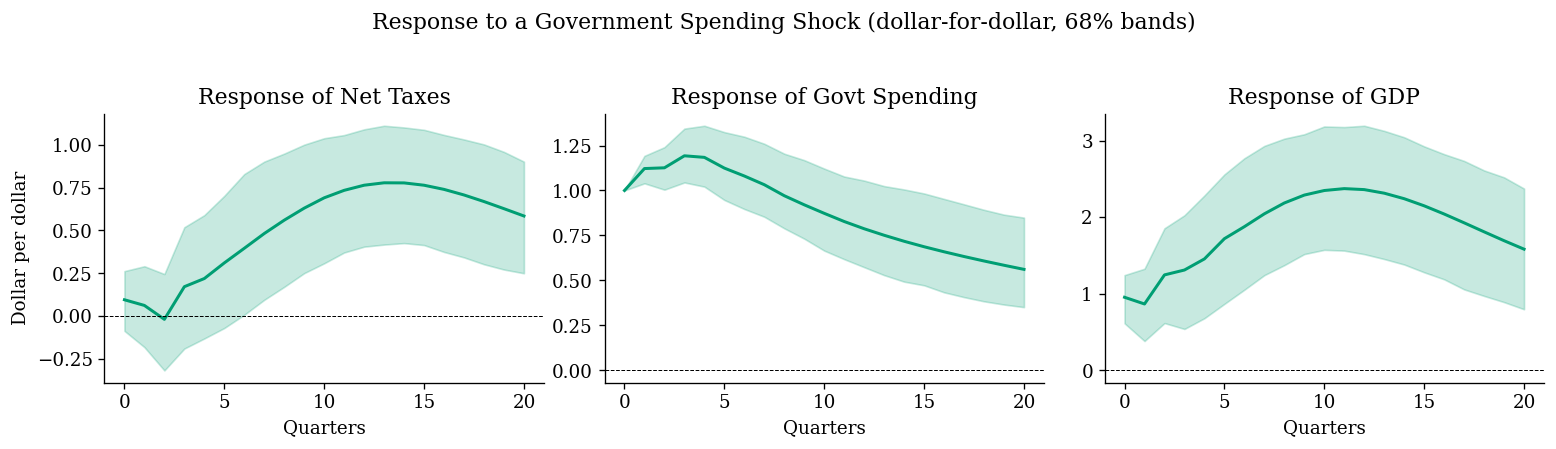

GDP response to G shock (dollar):  {'0q': np.float64(0.96), '4q': np.float64(1.46), '8q': np.float64(2.19), '12q': np.float64(2.36), '20q': np.float64(1.58)} | peak 2.37 at q11
G own response:                   {'0q': np.float64(1.0), '4q': np.float64(1.18), '8q': np.float64(0.97), '12q': np.float64(0.79), '20q': np.float64(0.56)}


In [19]:
pt, lo, hi = irf_with_bands(bench, shock_col=1, V_Y=V_Y_bench, a1=a1, horizon=H)
plot_irf(pt, lo, hi, ['Net Taxes','Govt Spending','GDP'],
         'Response to a Government Spending Shock (dollar-for-dollar, 68% bands)',
         '#009E73', 'bp_irf_spending.pdf')

q = [0,4,8,12,20]
print("GDP response to G shock (dollar): ", {f'{h}q': round(pt[h,2],2) for h in q},
      f"| peak {pt[:,2].max():.2f} at q{pt[:,2].argmax()}")
print("G own response:                  ", {f'{h}q': round(pt[h,1],2) for h in q})

### 7b. Net tax shock — benchmark vs cash-basis proxy

This is the punchline. Under the **benchmark** (full accrual net taxes) the tax channel is dead — GDP barely responds, because $a_1\approx b_{\text{ols}}$. Under the **cash-basis proxy** the channel reappears with the correct negative sign. We plot both.


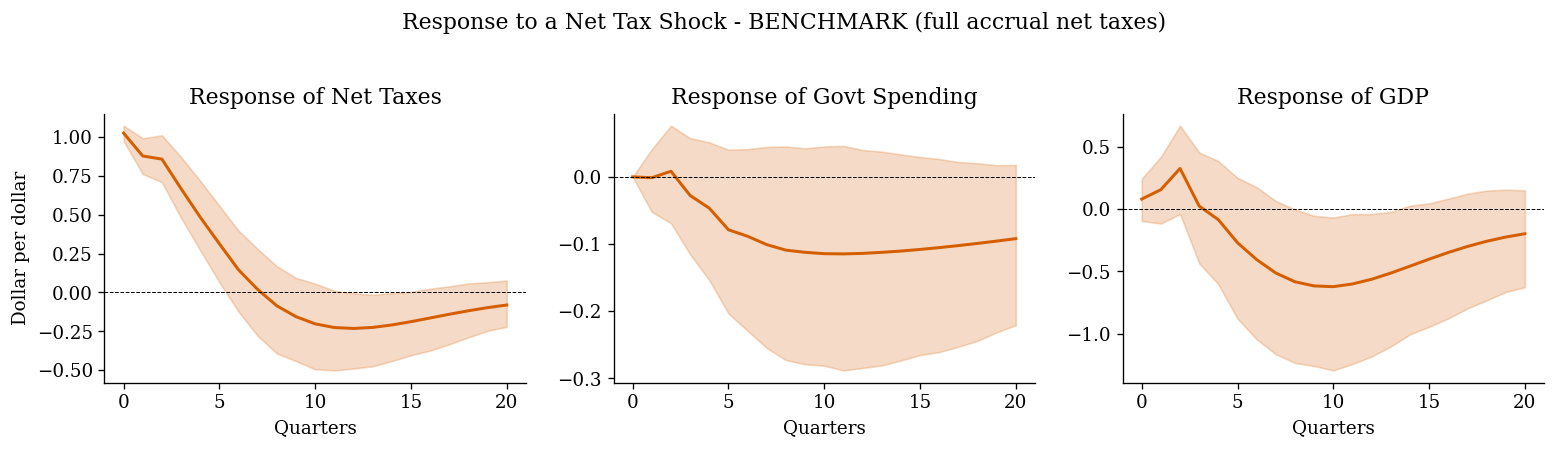

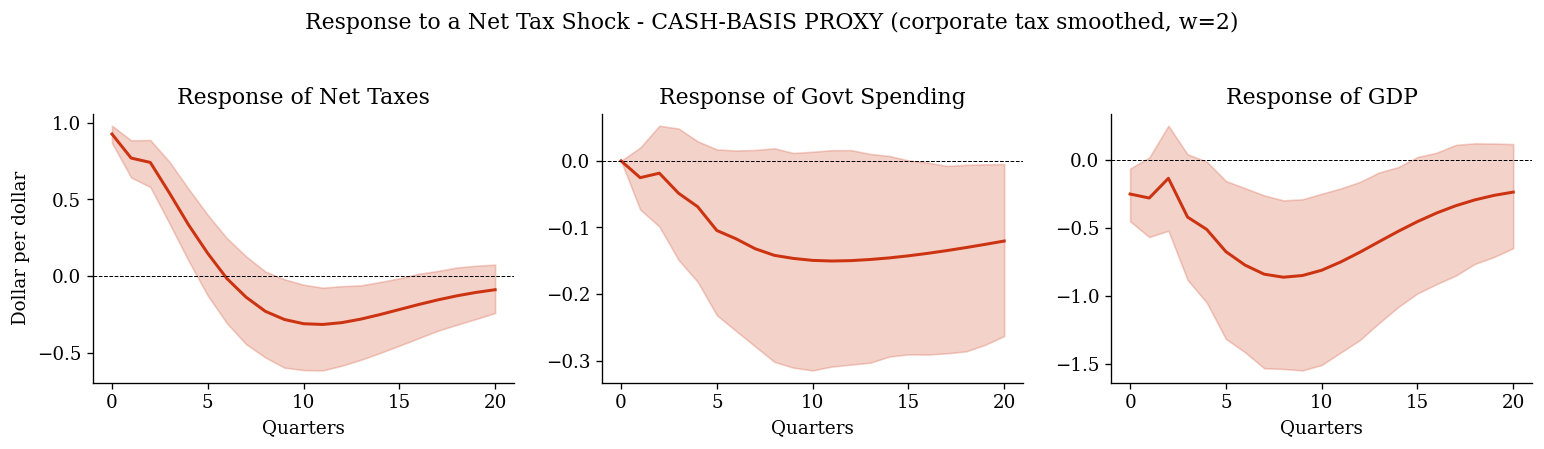

GDP response to T shock (dollar):
  benchmark: {'0q': np.float64(0.08), '4q': np.float64(-0.08), '8q': np.float64(-0.58), '12q': np.float64(-0.56), '20q': np.float64(-0.2)} | trough -0.62
  proxy    : {'0q': np.float64(-0.25), '4q': np.float64(-0.51), '8q': np.float64(-0.86), '12q': np.float64(-0.68), '20q': np.float64(-0.24)} | trough -0.86
  T own impact: benchmark 1.02, proxy 0.93  (BP: 0.74; <1 iff c1<0)


In [21]:
# Benchmark tax shock (channel ~ dead)
ptb, lob, hib = irf_with_bands(bench, shock_col=0, V_Y=V_Y_bench, a1=a1, horizon=H)
plot_irf(ptb, lob, hib, ['Net Taxes','Govt Spending','GDP'],
         'Response to a Net Tax Shock - BENCHMARK (full accrual net taxes)',
         '#D55E00', 'bp_irf_tax_benchmark.pdf')

# Proxy tax shock (channel restored)
ptp, lop, hip = irf_with_bands(proxy, shock_col=0, V_Y=V_Y_proxy, a1=a1, horizon=H)
plot_irf(ptp, lop, hip, ['Net Taxes','Govt Spending','GDP'],
         'Response to a Net Tax Shock - CASH-BASIS PROXY (corporate tax smoothed, w=2)',
         '#CC3311', 'bp_irf_tax_proxy.pdf')

print("GDP response to T shock (dollar):")
print("  benchmark:", {f'{h}q': round(ptb[h,2],2) for h in q}, f"| trough {ptb[:,2].min():.2f}")
print("  proxy    :", {f'{h}q': round(ptp[h,2],2) for h in q}, f"| trough {ptp[:,2].min():.2f}")
print(f"  T own impact: benchmark {ptb[0,0]:.2f}, proxy {ptp[0,0]:.2f}  (BP: 0.74; <1 iff c1<0)")

## 8. Multiplier summary vs BP Tables III–IV

The output multiplier is the trough/peak GDP response (dollar-for-dollar). We compare the impact, 4-quarter, and peak/trough responses against BP's reported figures.


In [23]:
def summ(pt, col=2):
    s = pt[:,col]
    return dict(impact=round(s[0],2), q4=round(s[4],2),
                peak=round(s[np.argmax(np.abs(s))],2),
                peak_q=int(np.argmax(np.abs(s))))

tab = pd.DataFrame({
    'Spending->GDP (ours)':      summ(pt),
    'BP Tab.IV DT (spending)':   {'impact':0.84,'q4':0.45,'peak':1.29,'peak_q':15},
    'Tax->GDP benchmark (ours)': summ(ptb),
    'Tax->GDP proxy (ours)':     summ(ptp),
    'BP Tab.III DT (tax)':       {'impact':-0.69,'q4':-0.74,'peak':-0.78,'peak_q':5},
}).T
print(tab.to_string())

print("\nContemporaneous (Table II):")
print(f"  c2 spending = {bench['ident']['c2']/G_Y:.3f}   (BP 0.956)")
print(f"  c1 tax benchmark = {bench['ident']['c1']/T_Y:.3f}   (BP -0.868)")
print(f"  c1 tax proxy     = {proxy['ident']['c1']/T_Y_sm:.3f}   (BP -0.868)")

                           impact    q4  peak  peak_q
Spending->GDP (ours)         0.96  1.46  2.37    11.0
BP Tab.IV DT (spending)      0.84  0.45  1.29    15.0
Tax->GDP benchmark (ours)    0.08 -0.08 -0.62    10.0
Tax->GDP proxy (ours)       -0.25 -0.51 -0.86     8.0
BP Tab.III DT (tax)         -0.69 -0.74 -0.78     5.0

Contemporaneous (Table II):
  c2 spending = 0.948   (BP 0.956)
  c1 tax benchmark = 0.078   (BP -0.868)
  c1 tax proxy     = -0.273   (BP -0.868)


## 9. Conclusions

We replicate the Blanchard–Perotti three-variable SVAR on current FRED data (general government, real per-capita logs, 1960Q1–1997Q4, deterministic-trend specification). The results split cleanly into a robust channel and a fragile one.

**The spending channel reproduces.** The contemporaneous spending coefficient is $c_2 = 0.948$ (BP Table II: $0.956$) — almost exact. The spending IRF on GDP starts at $0.96$ (BP Table IV impact: $0.84$) and is positive, bell-shaped, and persistent, as in BP. The one notable departure is the **peak**: our GDP response builds to $2.37$ around quarter 11, versus BP's $1.29$ at quarter 15. The impact matches but the dynamics amplify more under revised data — consistent with BP's own finding (Table V) that the spending multiplier is unstable across subsamples (ranging $0.62$–$1.80$); our peak sits above that range but in the same spirit of fragility.

**The tax channel does not reproduce out of the box.** With current **accrual-basis** NIPA data, net taxes are slightly too procyclical ($b_{\text{ols}} = 2.114 > a_1 = 2.08$), and the tax channel collapses: the GDP-on-tax IRF even shows a perverse positive impact ($+0.08$) and only a shallow trough ($-0.62$). The contemporaneous $c_1 = 0.078$ has the wrong sign relative to BP's $-0.868$.

**The cause is the corporate income tax.** A component worth only ~10% of receipts, but strongly procyclical on an accrual basis, lifts $b_{\text{ols}}$ above $a_1$ and flips $c_1$ to ≈ 0 — through its *comovement* with output, not its volatility (removing it barely changes $\mathrm{sd}(v^T)$). BP sidestep this by using **cash-basis** corporate-tax data from the Treasury Bulletin, which collection lags make far less contemporaneously procyclical. That series is not on FRED.

**Approximating the cash-basis treatment restores the channel.** Replacing the accrual corporate tax with a 2-quarter moving average (a proxy for collection lags) lowers $b_{\text{ols}}$ to $1.622$, below $a_1$, and the tax channel reappears: $c_1 = -0.273$, with a GDP trough of $-0.86$ at quarter 8 — between BP's DT ($-0.78$) and ST ($-1.33$) troughs — and the BP-shaped gradual build-up. The own-tax impact falls to $0.93 < 1$ (BP: $0.74$), the signature of the negative feedback from output to revenues when $c_1 < 0$. The impact magnitude is weaker than BP's $-0.69$ because our $c_1$ ($-0.27$) is smaller than theirs ($-0.87$): we approximate the cash-basis correction, we do not replicate it.

> **This is a proxy, not BP's method.** BP use a different data *source* (cash-basis Treasury data); we apply a smoothing *transformation* to accrual data as a stand-in for collection lags. The qualitative finding is robust to the smoothing window; only the exact decimal of $c_1$ depends on it.

**Takeaway.** The exercise localizes the paper's fragility precisely. The spending result is robust to data vintage (with amplified dynamics). The tax result hinges on a corporate-tax data treatment documented only in an appendix footnote — and that detail turns out to be first-order: it is the difference between a tax channel that works and one that vanishes.

**Caveats and what we did not do.** FRED data are revised relative to BP's Citibase vintage; we target signs, shapes, and approximate magnitudes, not exact decimals. We report the deterministic-trend (DT) specification only; the stochastic-trend (ST) variant (first-differencing with a slowly-changing drift) would typically deliver larger, more persistent responses. Identification uses the spending-first ordering ($b_2 = 0$); BP show the ordering barely matters. A fully faithful tax-channel replication would require the cash-basis Treasury/MTS series or Perotti's original dataset.